# 06 — EDA Advanced

MWI distribution and patterns by training category.  Group comparison profiles. Correspondence Analysis of training category × categorical variables.

In [60]:
import sys
!{sys.executable} -m pip install prince --quiet

python(85901) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import prince
from scipy import stats as _stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

DATA_PATH   = '../data/processed/combined_data.csv'
OUTPUT_PATH = '../data/processed/analysis_ready.csv'

df = pd.read_csv(DATA_PATH)


## Setup — Variable Encoding

Ordinal and binary encodings applied to categorical columns. Original columns are retained; encoded columns get an `_enc` suffix.

In [62]:
# Ordinal / nominal encoding maps
AGE_MAP      = {'18-29': 1, '30-39': 2, '40-49': 3, '50-59': 4, '60+': 5}
GENDER_MAP   = {'Female': 0, 'Male': 1, 'Other': 2}
VOLUME_MAP   = {'Less than 2 hours': 1, '2–5 hours': 2, '5–10 hours': 3, 'More than 10 hours': 4}
INJURY_MAP   = {'No': 0, 'Yes': 1}
PAIN_MAP     = {'No pain': 0, 'Mild pain': 1, 'Moderate pain': 2, 'Severe pain': 3}
SLEEP_DUR_MAP = {'Less than 4 hours': 1, '6–8 hours': 2, 'More than 8 hours': 3}
END_RANGE_MAP = {'Never': 0, 'Sometimes': 1, 'Often': 2, 'Always': 3}
HYPER_MAP    = {'No': 0, 'Yes': 1}
TRAINING_MAP = {'Low Active': 1, 'Unclassified': 2, 'Strength-dominant': 3, 'Hybrid': 4, 'Flexibility-dominant': 5}
EARLY_LIFE_MAP = {
    'Flexibility-based': 1,
    'Endurance-based':   2,
    'Mixed / hybrid':    3,
    'Strength-based':    4,
    'No clear dominant': 5,
}

df_enc = df.copy()

df_enc['age_enc']           = df_enc['age_group'].map(AGE_MAP)
df_enc['gender_enc']        = df_enc['gender'].map(GENDER_MAP)
df_enc['volume_enc']        = df_enc['weekly_volume'].map(VOLUME_MAP)
df_enc['injury_enc']        = df_enc['injury_presence'].map(INJURY_MAP)
df_enc['pain_enc']          = df_enc['chronic_pain'].map(PAIN_MAP)
df_enc['sleep_dur_enc']     = df_enc['sleep_duration'].map(SLEEP_DUR_MAP)
df_enc['end_range_enc']     = df_enc['end_range_control'].map(END_RANGE_MAP)
df_enc['hypermobility_enc'] = df_enc['hypermobility'].map(HYPER_MAP)
df_enc['training_enc']      = df_enc['training_category'].map(TRAINING_MAP)
df_enc['early_life_enc']    = df_enc['early_life_training'].map(EARLY_LIFE_MAP)

print('Encoded dataframe shape:', df_enc.shape)
print('New encoded columns:', [
    'age_enc', 'gender_enc', 'volume_enc', 'injury_enc', 'pain_enc',
    'sleep_dur_enc', 'end_range_enc', 'hypermobility_enc', 'training_enc', 'early_life_enc'
])
df_enc.head()


Encoded dataframe shape: (25, 29)
New encoded columns: ['age_enc', 'gender_enc', 'volume_enc', 'injury_enc', 'pain_enc', 'sleep_dur_enc', 'end_range_enc', 'hypermobility_enc', 'training_enc', 'early_life_enc']


,name,age_group,gender,bmi,training_category,early_life_training,end_range_control,weekly_volume,injury_presence,chronic_pain,...,age_enc,gender_enc,volume_enc,injury_enc,pain_enc,sleep_dur_enc,end_range_enc,hypermobility_enc,training_enc,early_life_enc
0,P16,30-39,Male,25.7,Strength-dominant,Endurance-based,Sometimes,2–5 hours,No,Mild pain,...,2,1,2,0,1,2,1,0,3,2
1,P03,18-29,Female,22.2,Hybrid,Mixed / hybrid,Sometimes,2–5 hours,Yes,No pain,...,1,0,2,1,0,2,1,1,4,3
2,P24,50-59,Male,23.8,Low Active,Endurance-based,Always,Less than 2 hours,Yes,Moderate pain,...,4,1,1,1,2,2,3,0,1,2
3,P22,50-59,Female,22.8,Hybrid,Flexibility-based,Often,2–5 hours,No,No pain,...,4,0,2,0,0,2,2,0,4,1
4,P06,18-29,Female,20.3,Hybrid,Flexibility-based,Often,5–10 hours,No,No pain,...,1,0,3,0,0,2,2,1,4,1


## 1. MWI Distribution


In [63]:
mwi_n = df_enc['mwi'].notna().sum()
print(f'Participants with MWI score: {mwi_n} / {len(df_enc)}')
print(df_enc[df_enc['mwi'].notna()][['name', 'mwi']].to_string(index=False))

Participants with MWI score: 25 / 25
name      mwi
 P16 0.310957
 P03 0.261061
 P24 0.314544
 P22 0.255513
 P06 0.165492
 P12 0.365681
 P04 0.348187
 P19 0.357685
 P21 0.317126
 P05 0.249607
 P13 0.341417
 P09 0.182099
 P08 0.305743
 P20 0.357979
 P07 0.358620
 P01 0.385984
 P15 0.242828
 P17 0.250178
 P10 0.243653
 P25 0.310219
 P11 0.378183
 P14 0.109855
 P18 0.335961
 P23 0.229178
 P02 0.300946


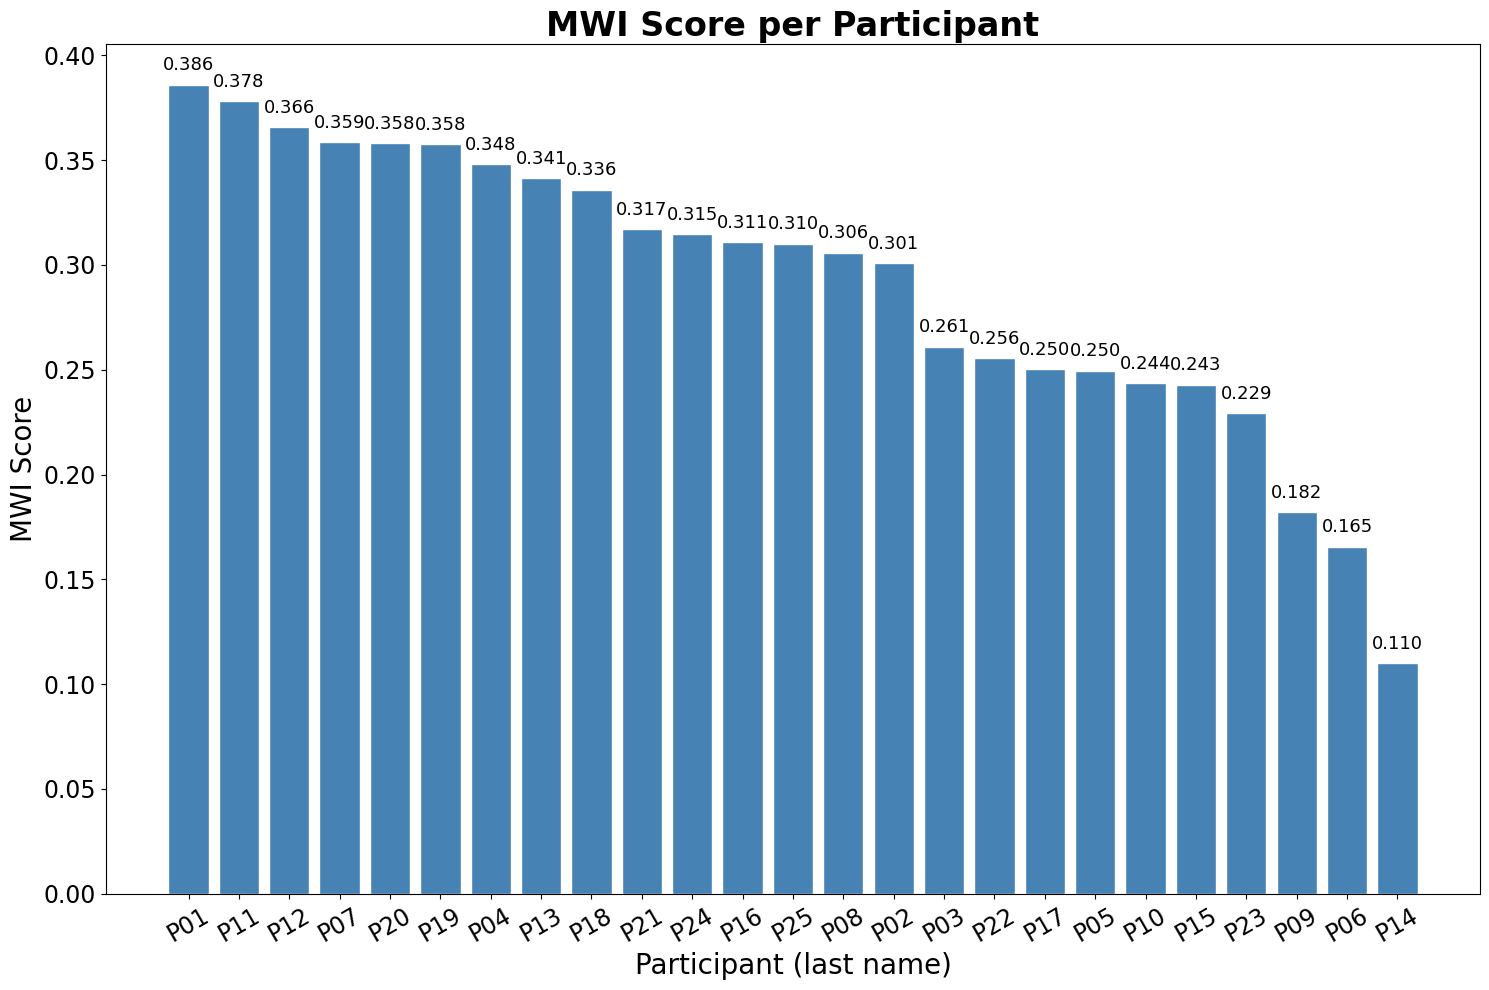

In [ ]:
# Bar chart of MWI scores per participant 
df_mwi_plot = df_enc[df_enc['mwi'].notna()][['name', 'mwi']].copy()
df_mwi_plot['label'] = df_mwi_plot['name'].apply(lambda x: x.strip().split()[-1])
df_mwi_plot = df_mwi_plot.sort_values('mwi', ascending=False)

fig, ax = plt.subplots(figsize=(15, 10))
bars = ax.bar(df_mwi_plot['label'], df_mwi_plot['mwi'], color='steelblue', edgecolor='white')
ax.set_title('MWI Score per Participant', fontsize=24, fontweight='bold')
ax.set_xlabel('Participant (last name)', fontsize=20)
ax.set_ylabel('MWI Score', fontsize=20)
ax.tick_params(axis='x', rotation=30, labelsize=17)
ax.tick_params(axis='y', labelsize=17)
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=13
    )
plt.tight_layout()
plt.show()


In [93]:
#  MWI distribution statistics 
import numpy as np
from scipy.stats import skew

mwi = df_enc['mwi'].dropna()
n      = len(mwi)
mean   = mwi.mean()
sd     = mwi.std()
median = mwi.median()
q1     = mwi.quantile(0.25)
q3     = mwi.quantile(0.75)
vmin   = mwi.min()
vmax   = mwi.max()
sk     = skew(mwi)

# Text histogram (5 bins)
counts, edges = np.histogram(mwi, bins=5)
print(f'MWI Distribution  (n={n})')
print('-' * 50)
print(f'  Mean ± SD   :  {mean:.2f} ± {sd:.2f}')
print(f'  Median [IQR]:  {median:.2f}  [{q1:.2f} – {q3:.2f}]')
print(f'  Range        :  {vmin:.2f} – {vmax:.2f}')
print(f'  Skewness     :  {sk:+.2f}')
print()
for cnt, lo, hi in zip(counts, edges[:-1], edges[1:]):
    pct = 100 * cnt / n
    bar = '█' * max(int(pct / 5), (1 if cnt > 0 else 0))
    print(f'  {lo:.2f} – {hi:.2f}   {cnt:3d} ({pct:5.1f}%)  {bar}')
print()
print(f'   Observed range covers '
      f'{(vmax - vmin):.2f} units ({(vmax-vmin)*100:.0f}% of scale)')


MWI Distribution  (n=25)
--------------------------------------------------
  Mean ± SD   :  0.29 ± 0.07
  Median [IQR]:  0.31  [0.25 – 0.35]
  Range        :  0.11 – 0.39
  Skewness     :  -0.80

  0.11 – 0.17     1 (  4.0%)  █
  0.17 – 0.22     2 (  8.0%)  █
  0.22 – 0.28     7 ( 28.0%)  █████
  0.28 – 0.33     6 ( 24.0%)  ████
  0.33 – 0.39     9 ( 36.0%)  ███████

   Observed range covers 0.28 units (28% of scale)


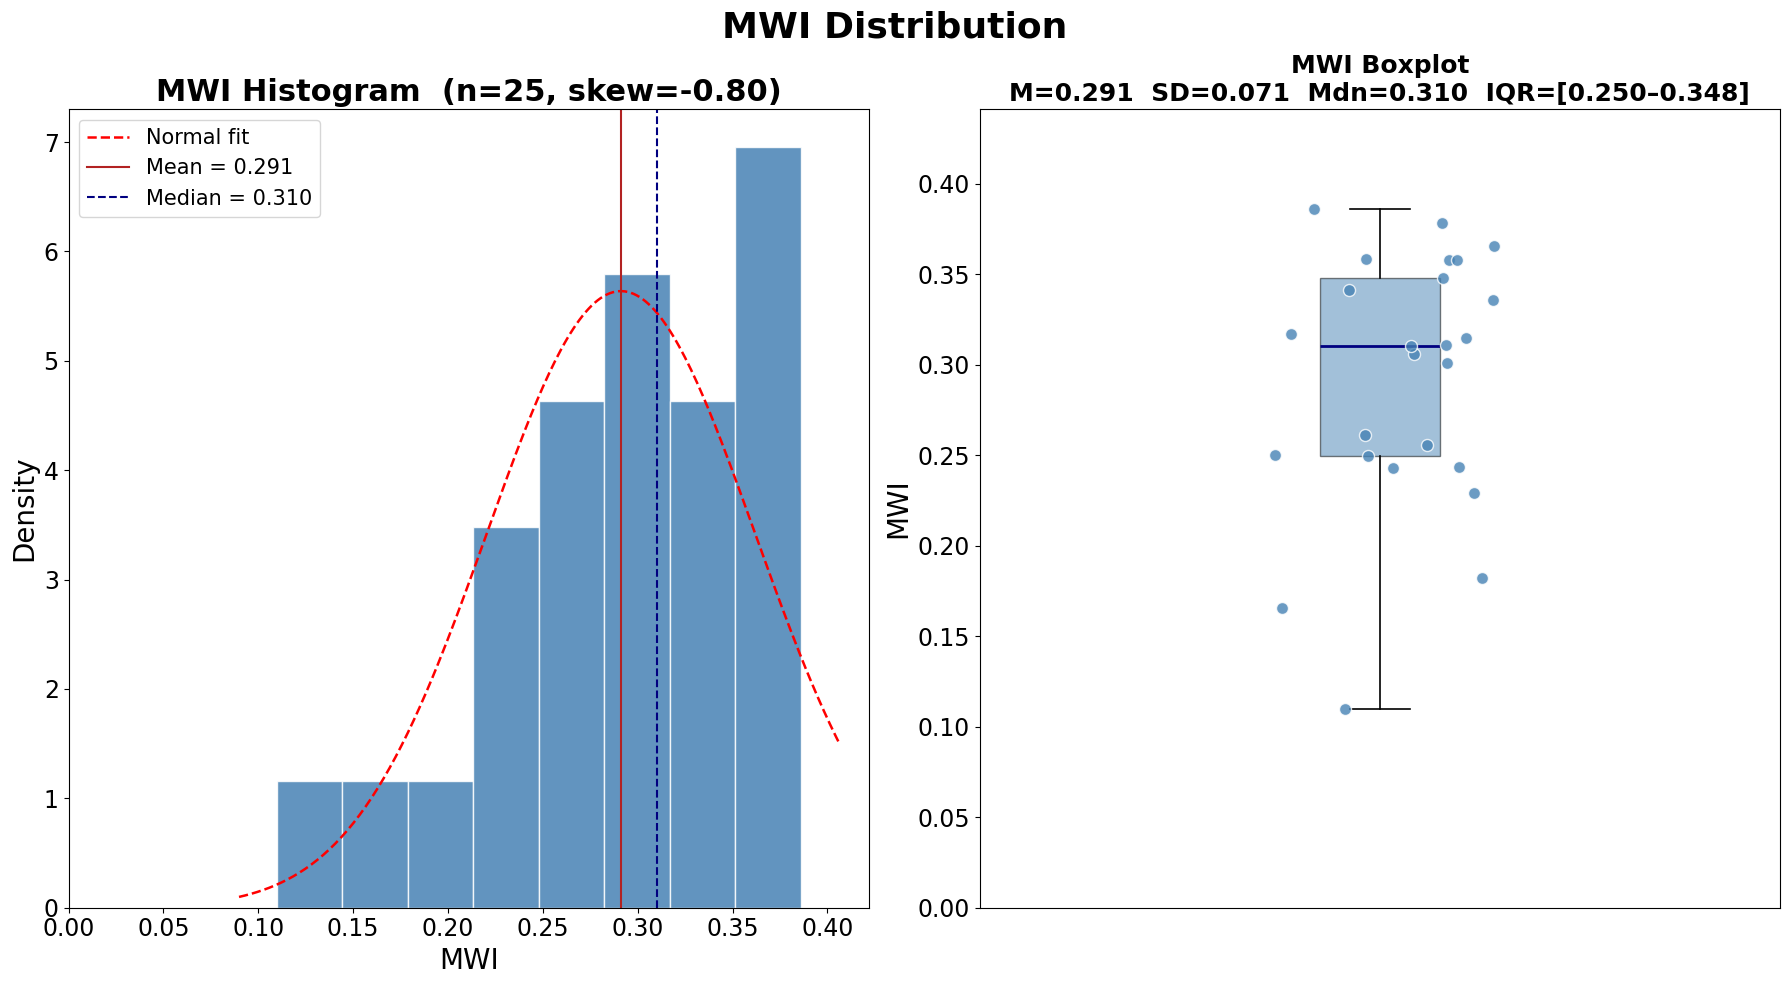

In [ ]:
from scipy.stats import skew, norm

mwi = df_enc['mwi'].dropna()

def draw_ybreak(ax, break_lo, break_hi, color='grey'):
    """Shade break zone and add diagonal markers on y-axis spine."""
    ax.axhspan(break_lo, break_hi, color='white', zorder=2)
    for yb in [break_lo, break_hi]:
        ax.axhline(yb, color=color, linewidth=0.6, linestyle='--', zorder=3)
    ylim = ax.get_ylim()
    for yb in [break_lo, break_hi]:
        y_ax = (yb - ylim[0]) / (ylim[1] - ylim[0])
        ax.plot([-0.015, 0.015], [y_ax - 0.012, y_ax + 0.012],
                transform=ax.transAxes, color='k', linewidth=1.2, clip_on=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

#  Left: Histogram with normal curve overlay 
ax = axes[0]
ax.hist(mwi, bins=8, color='steelblue', edgecolor='white', alpha=0.85, density=True)
xs = np.linspace(mwi.min() - 0.02, mwi.max() + 0.02, 200)
ax.plot(xs, norm.pdf(xs, mwi.mean(), mwi.std()), 'r--', lw=1.8, label='Normal fit')
ax.axvline(mwi.mean(),   color='firebrick', lw=1.5, linestyle='-',  label=f'Mean = {mwi.mean():.3f}')
ax.axvline(mwi.median(), color='navy',      lw=1.5, linestyle='--', label=f'Median = {mwi.median():.3f}')
ax.set_xlim(left=0)
ax.set_xlabel('MWI', fontsize=20)
ax.set_ylabel('Density', fontsize=20)
ax.tick_params(labelsize=17)
ax.set_title(f'MWI Histogram  (n={len(mwi)}, skew={skew(mwi):+.2f})', fontweight='bold', fontsize=22)
ax.legend(fontsize=15)

#  Right: Boxplot with individual points 
ax = axes[1]
data_min = float(mwi.min())
data_max = float(mwi.max())
y_top    = data_max + (data_max - data_min) * 0.2
ax.set_ylim(0, y_top)

ax.boxplot(mwi, vert=True, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.5),
           medianprops=dict(color='navy', lw=2),
           whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
           flierprops=dict(marker='o', markerfacecolor='firebrick', markersize=8),
           zorder=4)
rng = np.random.default_rng(42)
ax.scatter(rng.uniform(0.85, 1.15, len(mwi)), mwi,
           color='steelblue', edgecolor='white', s=75, alpha=0.8, zorder=5)


ax.set_xticks([])
ax.set_ylabel('MWI', fontsize=20)
ax.tick_params(axis='y', labelsize=17)
ax.set_title(
    f'MWI Boxplot\nM={mwi.mean():.3f}  SD={mwi.std():.3f}  '
    f'Mdn={mwi.median():.3f}  IQR=[{mwi.quantile(0.25):.3f}–{mwi.quantile(0.75):.3f}]',
    fontweight='bold', fontsize=18)

plt.suptitle('MWI Distribution', fontsize=26, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. MWI Patterns by Training Category

MWI by Training Category:
                       n    mean  median     std     min     max  diff_vs_overall_%  diff_vs_low_active_%     cv_%
training_category                                                                                                 
Low Active             3  0.3455  0.3360  0.0367  0.3145  0.3860            18.6670                0.0000  10.6114
Strength-dominant      5  0.3158  0.3110  0.0492  0.2437  0.3657             8.4619               -8.5998  15.5876
Flexibility-dominant   7  0.3001  0.3102  0.0513  0.2428  0.3580             3.0608              -13.1512  17.0985
Hybrid                10  0.2563  0.2583  0.0866  0.1099  0.3782           -11.9736              -25.8207  33.7728


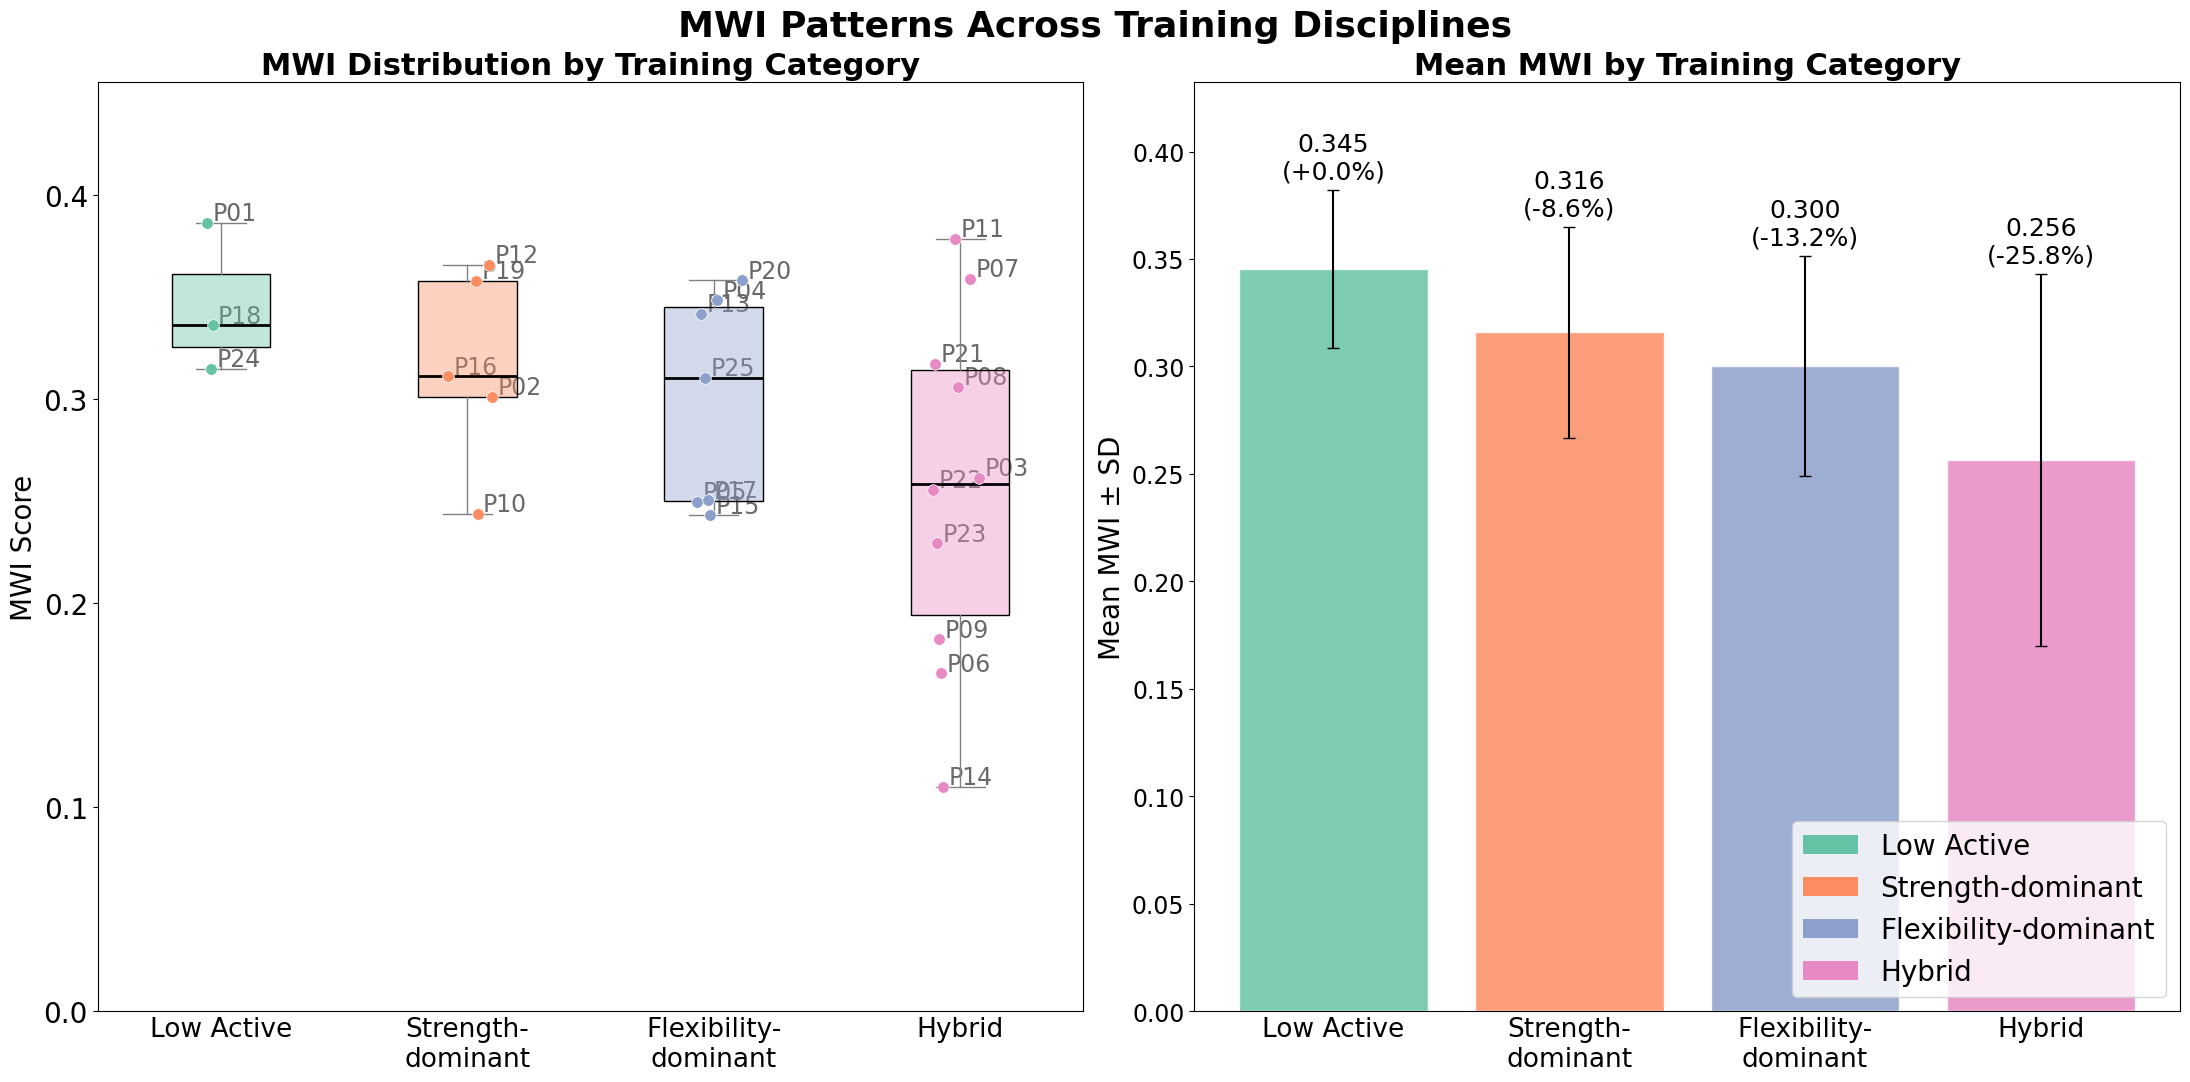

In [ ]:
df_mwi_train = df_enc[df_enc['mwi'].notna() & df_enc['training_category'].notna()].copy()

# Summary table 
summary = (
    df_mwi_train.groupby('training_category')['mwi']
    .agg(n='count', mean='mean', median='median', std='std', min='min', max='max')
)

overall_mean    = df_mwi_train['mwi'].mean()
low_active_mean = summary.loc['Low Active', 'mean'] if 'Low Active' in summary.index else np.nan

summary['diff_vs_overall_%']    = ((summary['mean'] - overall_mean) / overall_mean * 100)
summary['diff_vs_low_active_%'] = ((summary['mean'] - low_active_mean) / low_active_mean * 100)
summary['cv_%']                 = ((summary['std'] / summary['mean']) * 100)

summary = summary.round(4).sort_values('median', ascending=False)
print('MWI by Training Category:')
print(summary.to_string())

# Plot
cats_order = summary.index.tolist()
palette    = dict(zip(cats_order, plt.cm.Set2.colors[:len(cats_order)]))

all_vals = df_mwi_train['mwi']
data_min = float(all_vals.min())
data_max = float(all_vals.max())
y_top    = data_max + (data_max - data_min) * 0.25

fig, axes = plt.subplots(1, 2, figsize=(22, 11))

#  Left: Box + strip plot
ax.set_ylim(0, y_top)

for i, cat in enumerate(cats_order):
    vals      = df_mwi_train[df_mwi_train['training_category'] == cat]['mwi']
    cat_names = df_mwi_train[df_mwi_train['training_category'] == cat]['name']
    ax.boxplot(vals, positions=[i], widths=0.4, patch_artist=True,
               medianprops=dict(color='black', lw=2),
               boxprops=dict(facecolor=(*palette[cat][:3], 0.4)),
               whiskerprops=dict(color='grey'), capprops=dict(color='grey'),
               flierprops=dict(marker=''), zorder=4)
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals,
               color=palette[cat], s=70, zorder=5, edgecolor='white', linewidth=0.5)
    for j, (v, name) in enumerate(zip(vals, cat_names)):
        ax.annotate(name.strip().split()[-1], (i + jitter[j], v),
                    fontsize=17, color='dimgrey', xytext=(4, 2), textcoords='offset points')

ax.set_xticks(range(len(cats_order)))
ax.set_xticklabels([c.replace('-', '-\n') for c in cats_order], fontsize=19)
ax.set_ylabel('MWI Score', fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_title('MWI Distribution by Training Category', fontsize=22, fontweight='bold')
ax.tick_params(axis='x', length=0)

#  Right: Mean ± SD bar chart 
ax = axes[1]
means = summary['mean']
stds  = summary['std'].fillna(0)
y_top_bar = (means + stds).max() + 0.05
ax.set_ylim(0, y_top_bar)

bars = ax.bar(range(len(cats_order)), means, yerr=stds, capsize=4,
              color=[palette[c] for c in cats_order], edgecolor='white', alpha=0.85,
              zorder=4)

ax.set_xticks(range(len(cats_order)))
ax.set_xticklabels([c.replace('-', '-\n') for c in cats_order], fontsize=19)
ax.set_ylabel('Mean MWI ± SD', fontsize=20)
ax.tick_params(axis='y', labelsize=17)
ax.set_title('Mean MWI by Training Category', fontsize=22, fontweight='bold')

for bar, cat in zip(bars, cats_order):
    val = summary.loc[cat, 'mean']
    sd  = summary.loc[cat, 'std'] if pd.notna(summary.loc[cat, 'std']) else 0
    pct = summary.loc[cat, 'diff_vs_low_active_%']
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + sd + 0.003,
            f'{val:.3f}\n({pct:+.1f}%)',
            ha='center', va='bottom', fontsize=18, zorder=5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=palette[c], label=c) for c in cats_order]
ax.legend(handles=legend_elements, fontsize=20, loc='lower right')
ax.tick_params(axis='x', length=0)

plt.suptitle('MWI Patterns Across Training Disciplines', fontsize=26, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Group Comparisons

Comparisons of health, lifestyle, and mobility variables across training categories and other grouping variables.

=== Mean ± SD by Training Category ===

                Flexibility-dominant                Hybrid           Low Active    Strength-dominant   KW p
Variable                                                                                                   
BMI              21.40 ± 3.73  (n=7)  21.35 ± 1.03  (n=10)  23.40 ± 0.40  (n=3)  23.12 ± 3.52  (n=5)  0.083
Sleep Quality     5.37 ± 3.58  (n=7)   6.86 ± 1.89  (n=10)   6.23 ± 1.25  (n=3)   6.00 ± 1.65  (n=5)  0.430
Phys. Recovery    4.00 ± 1.83  (n=7)   3.80 ± 1.14  (n=10)   3.00 ± 1.73  (n=3)   2.20 ± 1.10  (n=5)  0.161
Mental Recovery   4.71 ± 1.60  (n=7)   4.20 ± 1.48  (n=10)   5.00 ± 1.00  (n=3)   4.00 ± 2.00  (n=5)  0.742
Stress            1.67 ± 1.11  (n=7)   0.93 ± 0.61  (n=10)   1.22 ± 0.19  (n=3)   1.00 ± 0.41  (n=5)  0.329
Sitting Time      7.86 ± 1.07  (n=7)   6.60 ± 1.58  (n=10)   7.00 ± 0.00  (n=3)   7.40 ± 1.67  (n=5)  0.333
MWI               0.30 ± 0.05  (n=7)   0.26 ± 0.09  (n=10)   0.35 ± 0.04  (n=3)   0.32 ± 0.05  (

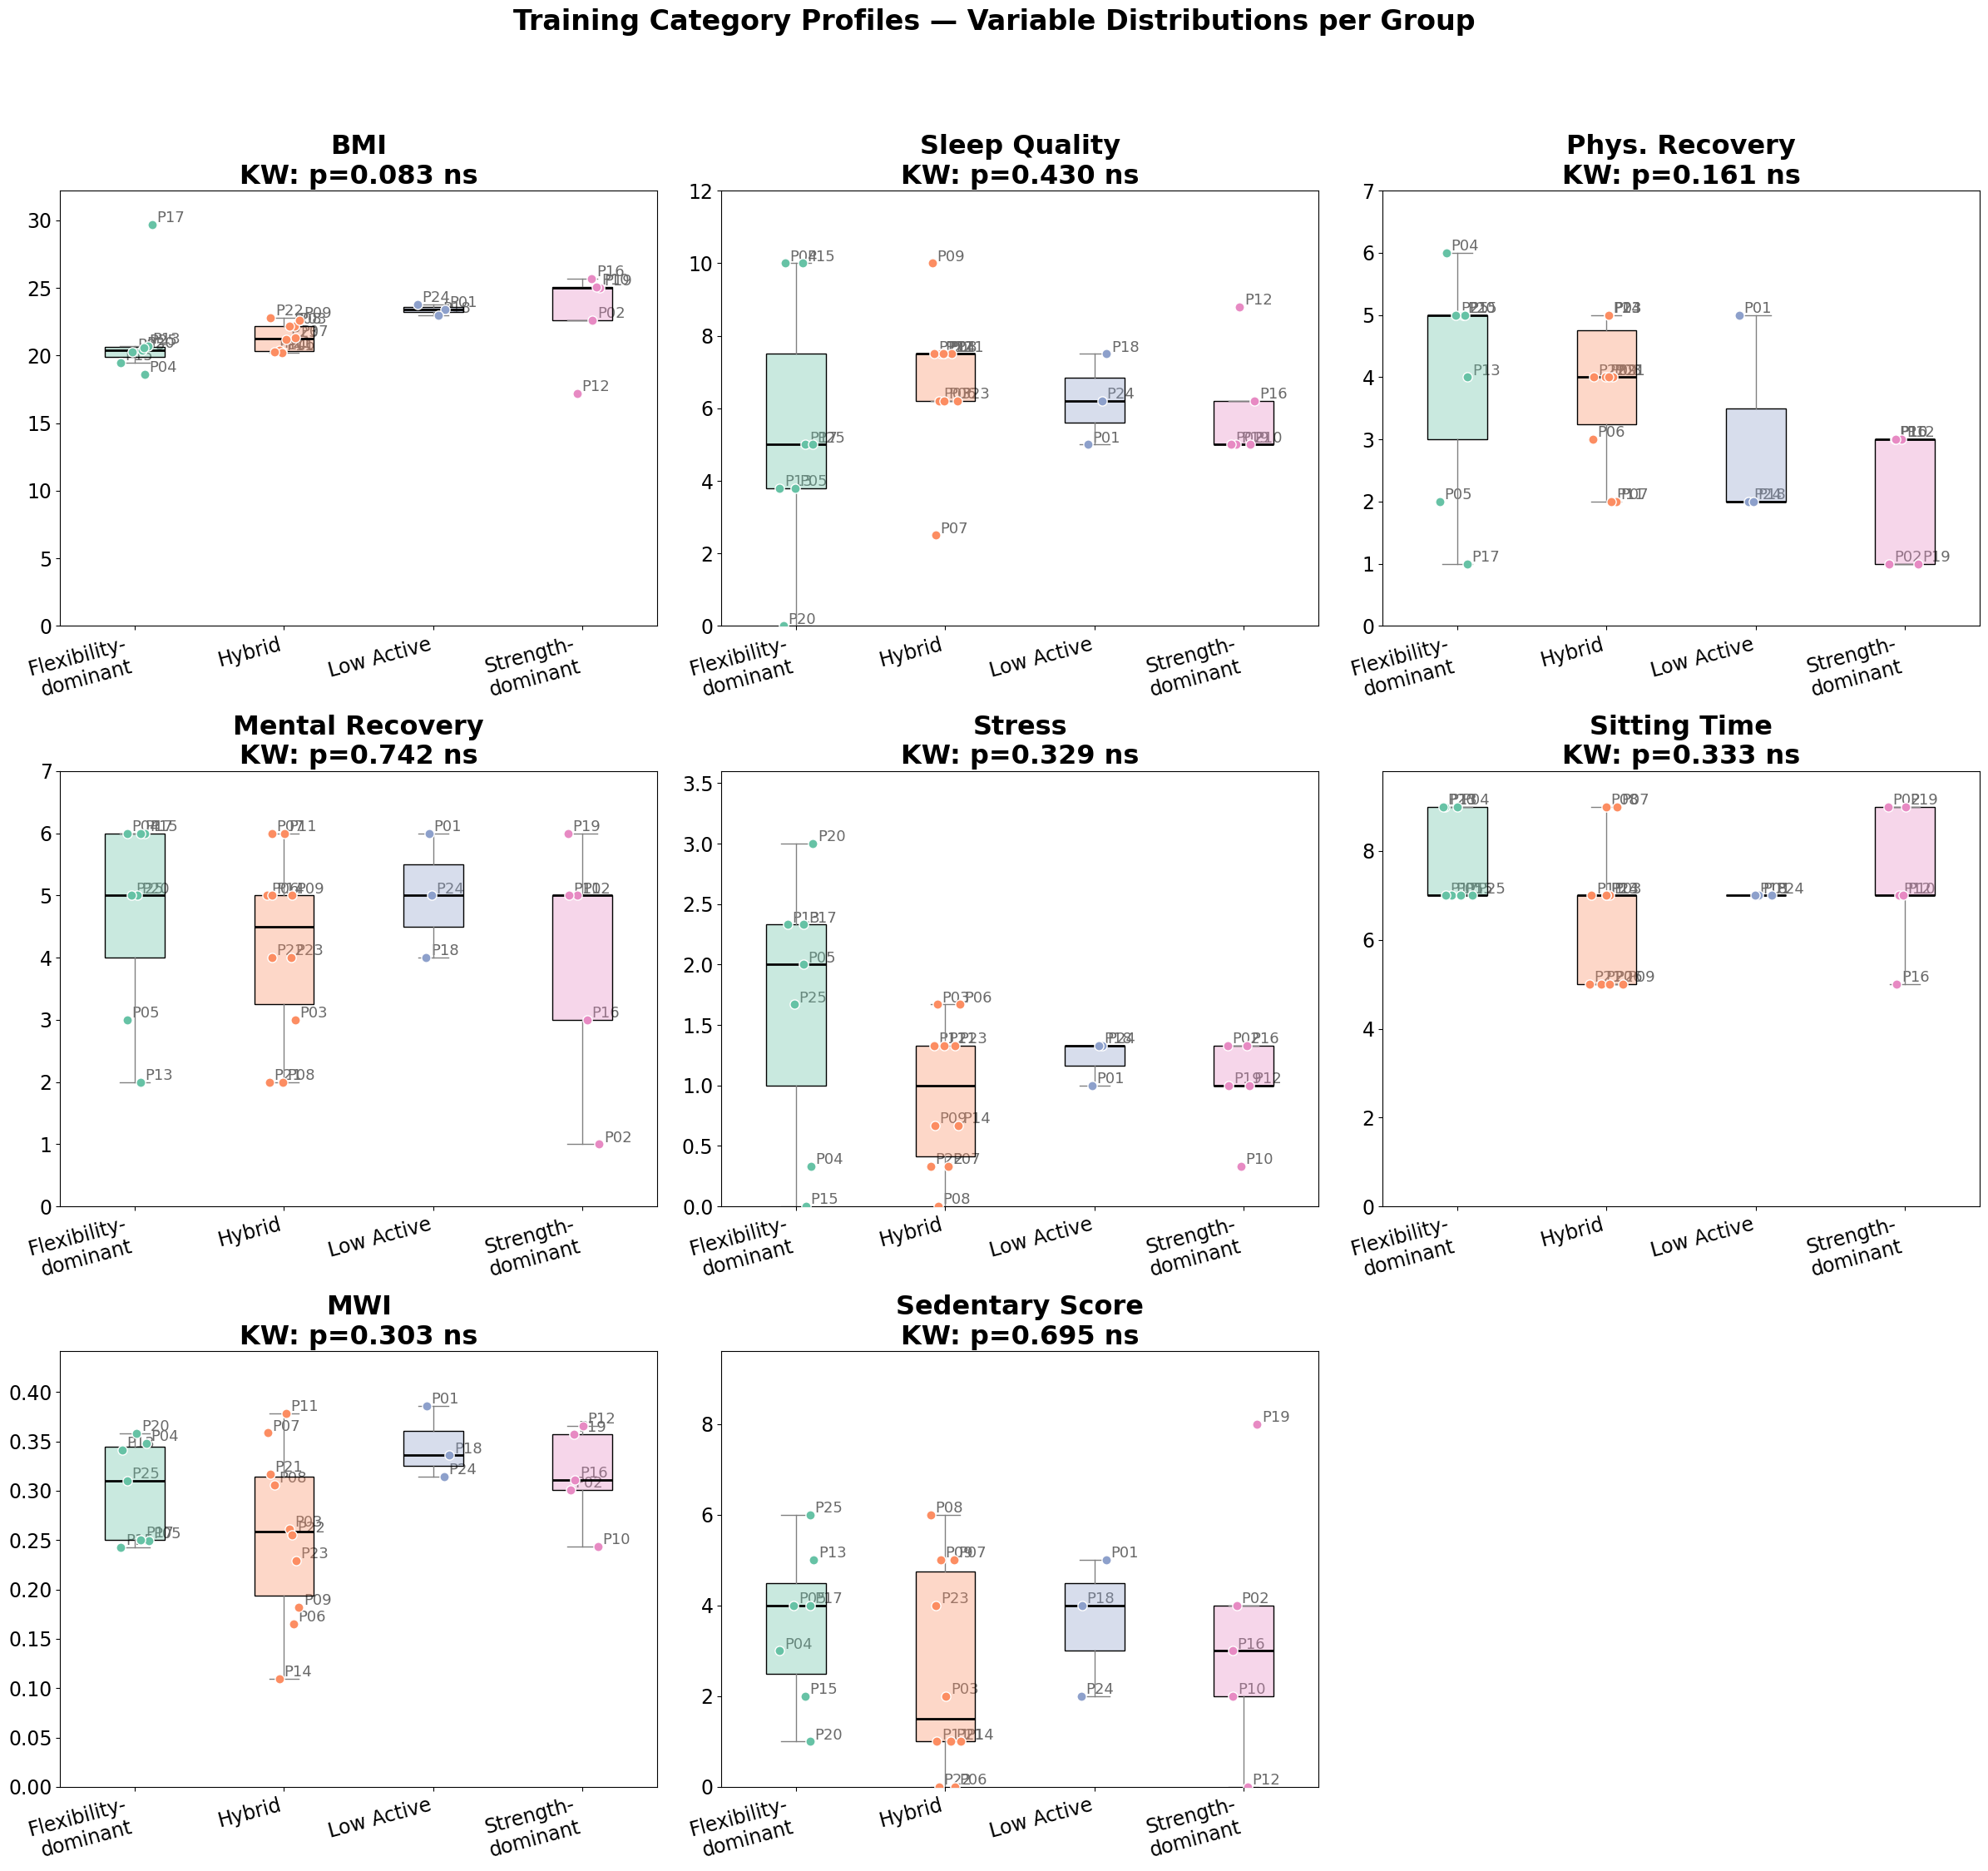

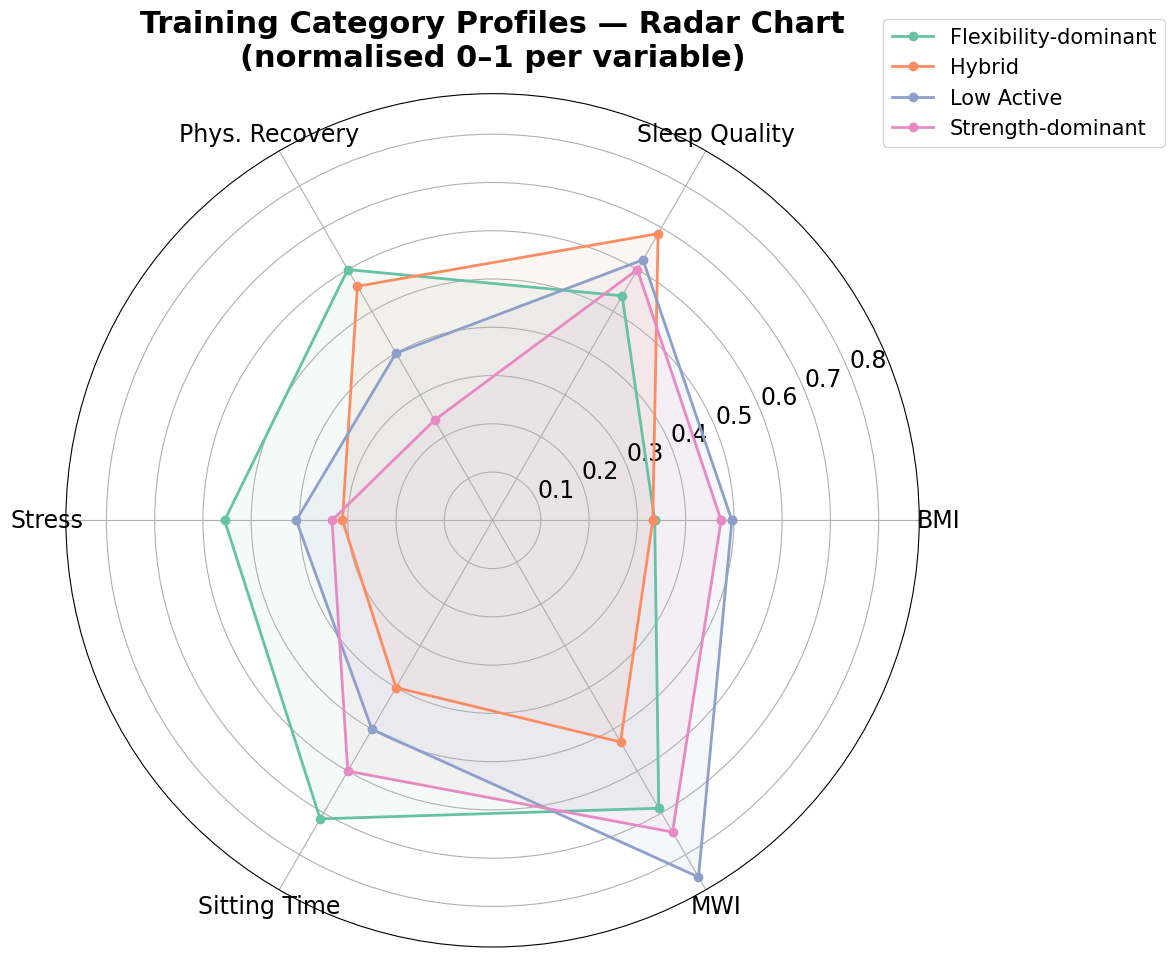

In [ ]:
PROFILE_COLS = {
    'bmi':              'BMI',
    'sleep_quality':    'Sleep Quality',
    'physical_recovery':'Phys. Recovery',
    'mental_recovery':  'Mental Recovery',
    'stress_score':     'Stress',
    'sitting_time':     'Sitting Time',
    'mwi':              'MWI',
    'sedentary_score':  'Sedentary Score',
}

cat_df = df_enc[list(PROFILE_COLS.keys()) + ['training_category', 'name']].dropna(subset=['training_category'])
cats   = sorted(cat_df['training_category'].dropna().unique())
cat_pal = {c: plt.cm.Set2.colors[i] for i, c in enumerate(cats)}

#  Group comparison table 
print('=== Mean ± SD by Training Category ===\n')
rows = []
for col, label in PROFILE_COLS.items():
    row = {'Variable': label}
    for cat in cats:
        sub = cat_df[cat_df['training_category'] == cat][col].dropna()
        row[cat] = f'{sub.mean():.2f} ± {sub.std():.2f}  (n={len(sub)})'
    groups = [cat_df[cat_df['training_category'] == c][col].dropna().values for c in cats]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        stat_kw, p_kw = _stats.kruskal(*groups)
        row['KW p'] = f'{p_kw:.3f}' + (' *' if p_kw < 0.05 else '')
    else:
        row['KW p'] = 'n/a'
    rows.append(row)

profile_tbl = pd.DataFrame(rows).set_index('Variable')
print(profile_tbl.to_string())

#  Boxplot grid 
n_cols_p = 3
n_rows_p = (len(PROFILE_COLS) + n_cols_p - 1) // n_cols_p
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(24, 6 * n_rows_p + 4))
axes = axes.flatten()
rng  = np.random.default_rng(42)

for ax, (col, label) in zip(axes, PROFILE_COLS.items()):
    order = [c for c in cats if cat_df[cat_df['training_category'] == c][col].notna().any()]

    all_vals = cat_df[col].dropna()
    data_max = float(all_vals.max())
    pad      = (data_max - float(all_vals.min())) * 0.2
    y_top    = data_max + pad
    ax.set_ylim(0, y_top)

    for i, cat in enumerate(order):
        mask  = (cat_df['training_category'] == cat) & cat_df[col].notna()
        vals  = cat_df[mask][col].values
        names = cat_df[mask]['name'].values
        ax.boxplot(vals, positions=[i], widths=0.4, patch_artist=True,
                   medianprops=dict(color='black', lw=2),
                   boxprops=dict(facecolor=(*cat_pal[cat][:3], 0.35)),
                   whiskerprops=dict(color='grey'), capprops=dict(color='grey'),
                   flierprops=dict(marker=''), zorder=4)
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=cat_pal[cat], s=65, zorder=5, edgecolor='white')
        for j, (v, name) in enumerate(zip(vals, names)):
            ax.annotate(name.strip().split()[-1], (i + jitter[j], v),
                        fontsize=13, color='dimgrey', xytext=(4, 2),
                        textcoords='offset points')

    groups = [cat_df[cat_df['training_category'] == c][col].dropna().values for c in order]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) >= 2:
        _, p_kw = _stats.kruskal(*groups)
        p_str = f'p={p_kw:.3f}' if p_kw >= 0.001 else 'p<0.001'
        sig   = '**' if p_kw < 0.01 else ('*' if p_kw < 0.05 else 'ns')
        ax.set_title(f'{label}\nKW: {p_str} {sig}', fontsize=23, fontweight='bold')
    else:
        ax.set_title(label, fontsize=18, fontweight='bold')

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([c.replace('-', '-\n') for c in order],
                       fontsize=17, rotation=15, ha='right')
    ax.tick_params(axis='y', labelsize=17)

for j in range(len(PROFILE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Training Category Profiles — Variable Distributions per Group',
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

#  Radar 
RADAR_COLS   = ['bmi', 'sleep_quality', 'physical_recovery', 'stress_score', 'sitting_time', 'mwi']
RADAR_LABELS = ['BMI', 'Sleep Quality', 'Phys. Recovery', 'Stress', 'Sitting Time', 'MWI']

norm_df = cat_df[RADAR_COLS + ['training_category']].dropna().copy()
for col in RADAR_COLS:
    mn, mx = norm_df[col].min(), norm_df[col].max()
    norm_df[col] = (norm_df[col] - mn) / (mx - mn) if mx > mn else 0.0

n_ax    = len(RADAR_COLS)
angles  = np.linspace(0, 2*np.pi, n_ax, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
for cat in cats:
    sub  = norm_df[norm_df['training_category'] == cat][RADAR_COLS].mean().values.tolist()
    sub += sub[:1]
    ax.plot(angles, sub, 'o-', linewidth=2, color=cat_pal[cat], label=cat)
    ax.fill(angles, sub, alpha=0.08, color=cat_pal[cat])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, fontsize=17)
ax.tick_params(labelsize=17)
ax.set_title('Training Category Profiles — Radar Chart\n(normalised 0–1 per variable)',
             fontweight='bold', fontsize=22, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=15)
plt.tight_layout()
plt.show()


### Categorical Variable Profiles by Training Category

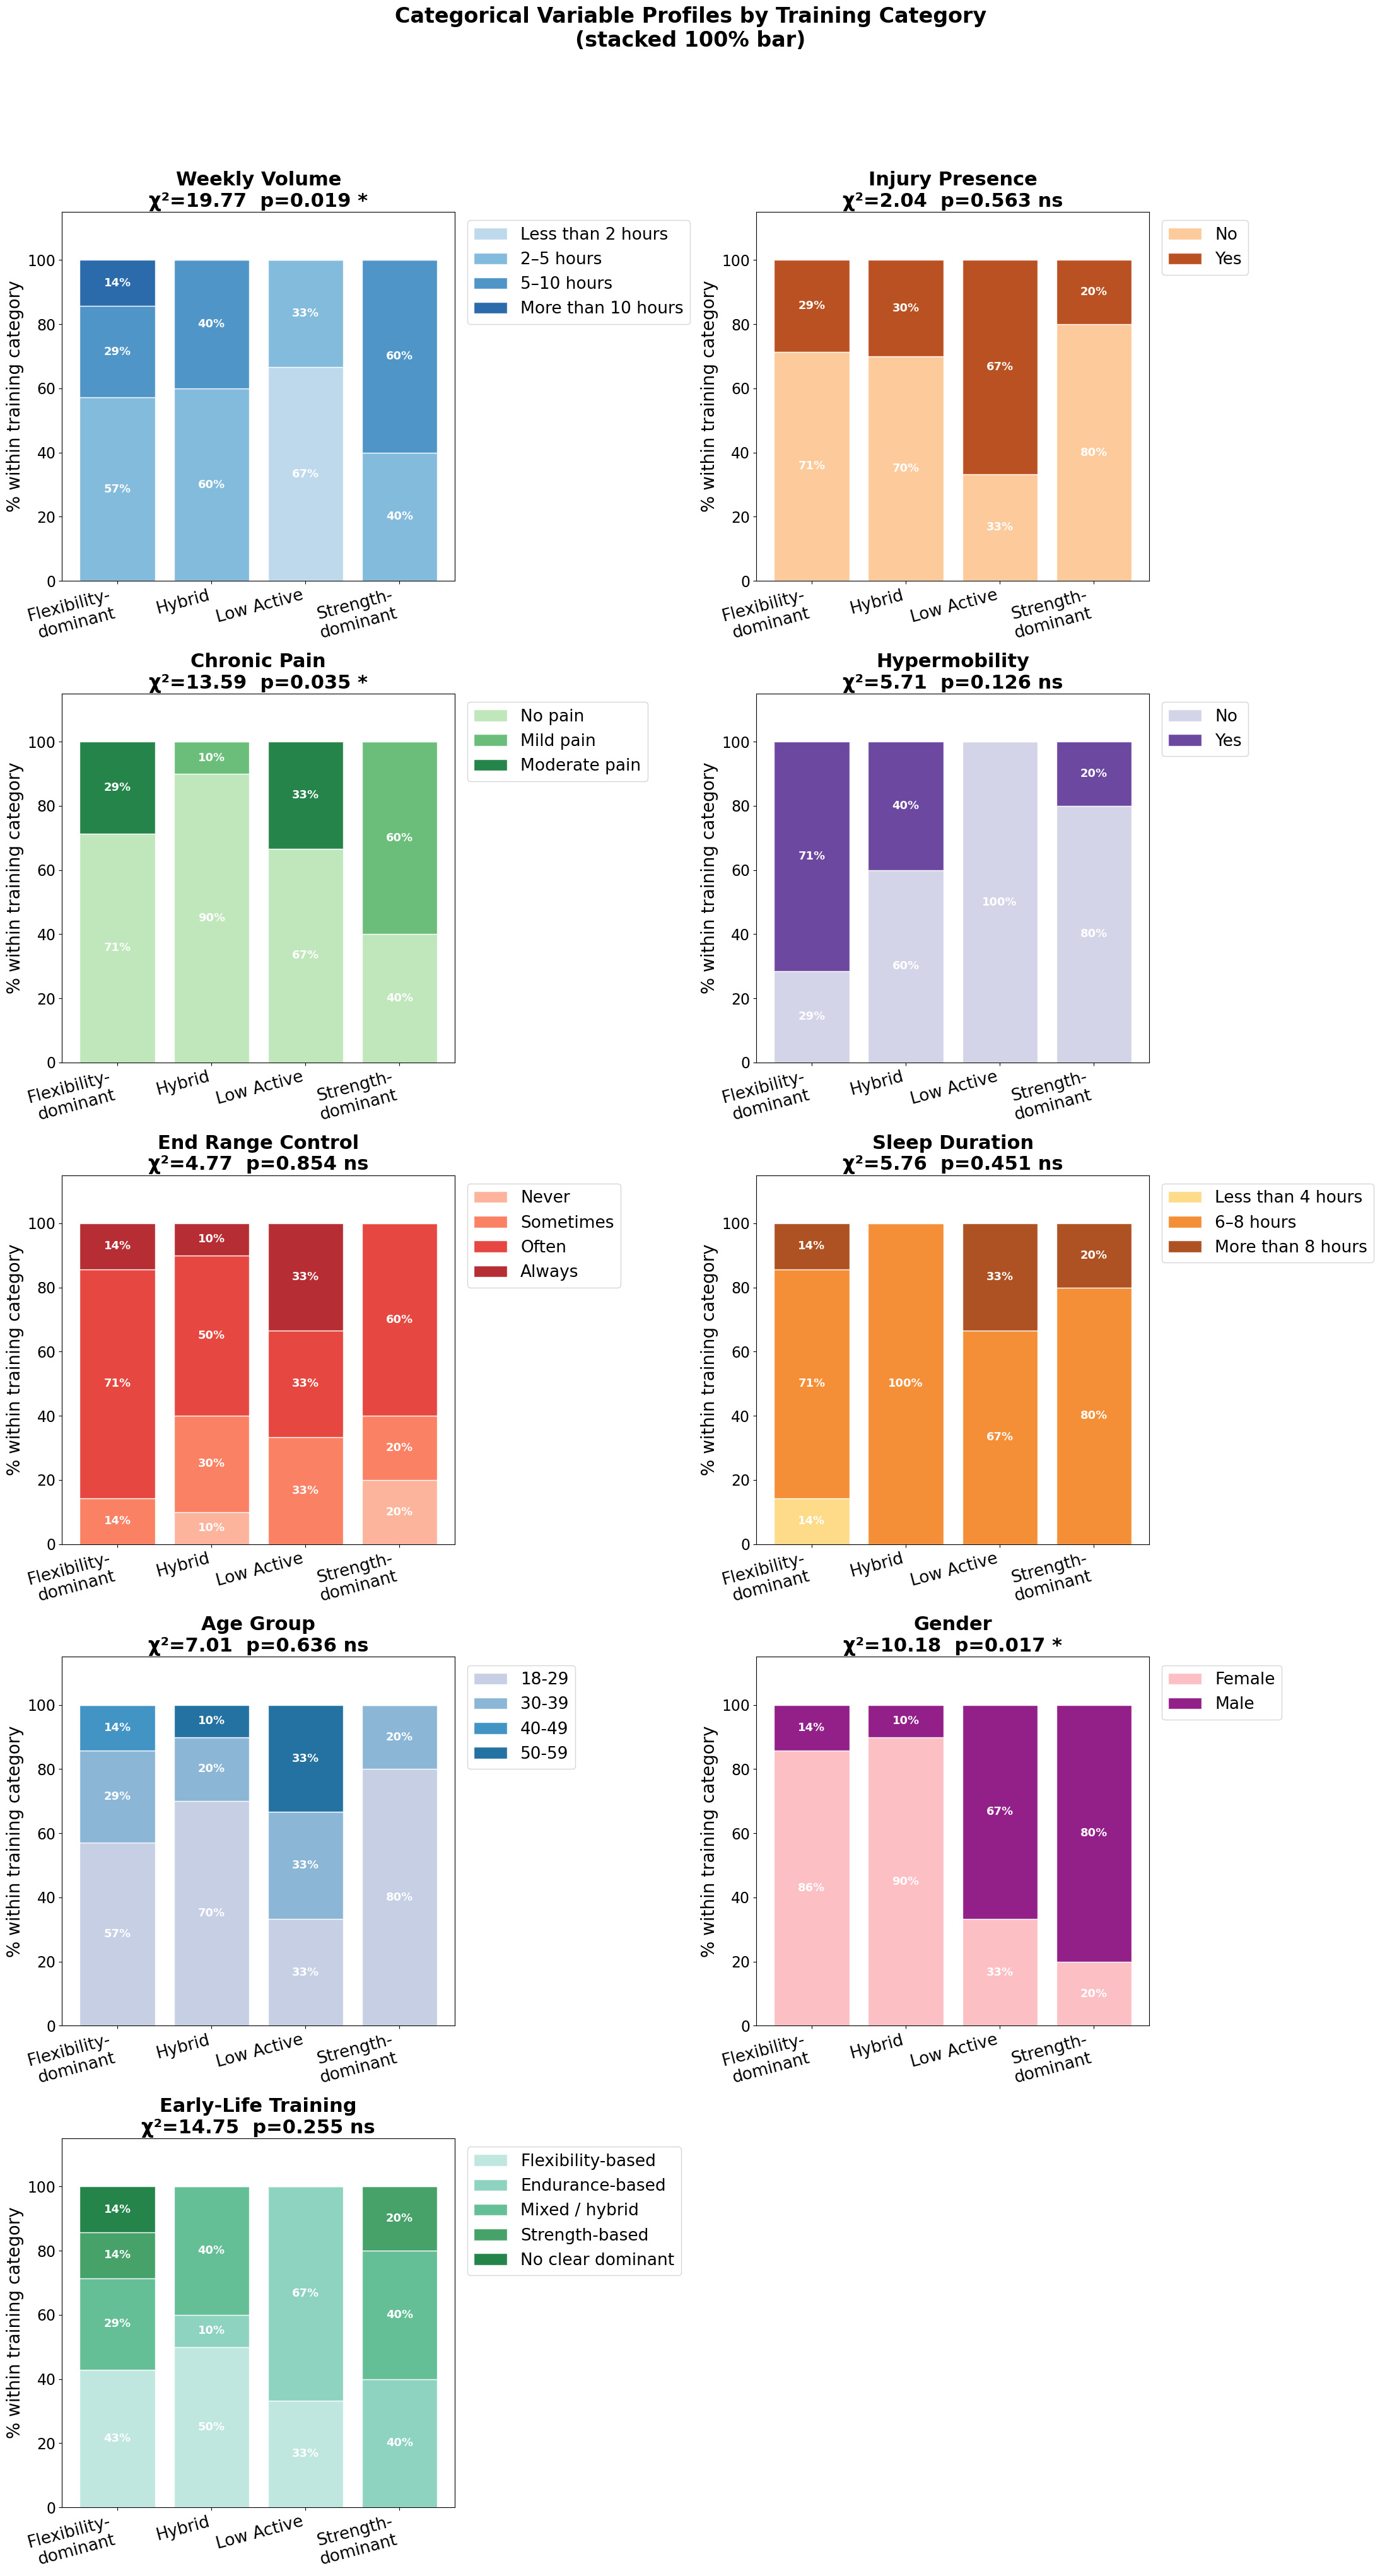

In [ ]:
CAT_PROFILE_VARS = [
    ('weekly_volume',     'Weekly Volume',       ['Less than 2 hours', '2–5 hours', '5–10 hours', 'More than 10 hours']),
    ('injury_presence',    'Injury Presence',     ['No', 'Yes']),
    ('chronic_pain',       'Chronic Pain',         ['No pain', 'Mild pain', 'Moderate pain']),
    ('hypermobility',      'Hypermobility',        ['No', 'Yes']),
    ('end_range_control',  'End Range Control',    ['Never', 'Sometimes', 'Often', 'Always']),
    ('sleep_duration',     'Sleep Duration',       ['Less than 4 hours', '6–8 hours', 'More than 8 hours']),
    ('age_group',          'Age Group',            ['18-29', '30-39', '40-49', '50-59']),
    ('gender',             'Gender',               ['Female', 'Male']),
    ('early_life_training','Early-Life Training',  ['Flexibility-based', 'Endurance-based', 'Mixed / hybrid', 'Strength-based', 'No clear dominant']),
]

cat_base = df_enc[['training_category'] + [v for v, _, _ in CAT_PROFILE_VARS]].dropna(subset=['training_category'])
train_cats = sorted(cat_base['training_category'].dropna().unique())


#  Stacked 100% bar chart
CMAPS = ['Blues', 'Oranges', 'Greens', 'Purples', 'Reds', 'YlOrBr', 'PuBu', 'RdPu', 'BuGn']

ncols = 2
nrows = (len(CAT_PROFILE_VARS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 8 * nrows))
axes = axes.flatten()

for ax_idx, (col, label, order) in enumerate(CAT_PROFILE_VARS):
    ax = axes[ax_idx]

    sub = cat_base[['training_category', col]].dropna()
    ct  = pd.crosstab(sub['training_category'], sub[col])
    present_order = [o for o in order if o in ct.columns]
    ct  = ct[present_order]
    ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100)

    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2_val, p_chi, _, _ = _stats.chi2_contingency(ct.values)
        p_str = f'χ²={chi2_val:.2f}  p={p_chi:.3f}' + (' *' if p_chi < 0.05 else ' ns')
    else:
        p_str = ''

    cmap   = plt.get_cmap(CMAPS[ax_idx % len(CMAPS)])
    n_cat  = len(present_order)
    colors = [cmap(0.3 + 0.55 * i / max(n_cat - 1, 1)) for i in range(n_cat)]

    bottoms = np.zeros(len(train_cats))
    for ci, resp in enumerate(present_order):
        vals = ct_pct[resp].reindex(train_cats, fill_value=0).values
        ax.bar(range(len(train_cats)), vals, bottom=bottoms,
               color=colors[ci], edgecolor='white', alpha=0.88, label=resp)
        for bi, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 7:
                ax.text(bi, bot + v / 2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=13,
                        color='white', fontweight='bold')
        bottoms += vals

    ax.set_xticks(range(len(train_cats)))
    ax.set_xticklabels([c.replace('-', '-\n') for c in train_cats],
                       fontsize=19, rotation=15, ha='right')
    ax.set_ylabel('% within training category', fontsize=20)
    ax.tick_params(axis='y', labelsize=17)
    ax.set_ylim(0, 115)
    ax.set_title(f'{label}\n{p_str}', fontsize=22, fontweight='bold')
    ax.legend(fontsize=19, bbox_to_anchor=(1.01, 1), loc='upper left')

for j in range(len(CAT_PROFILE_VARS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Variable Profiles by Training Category\n(stacked 100% bar)',
             fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


### MWI by Gender and Hypermobility

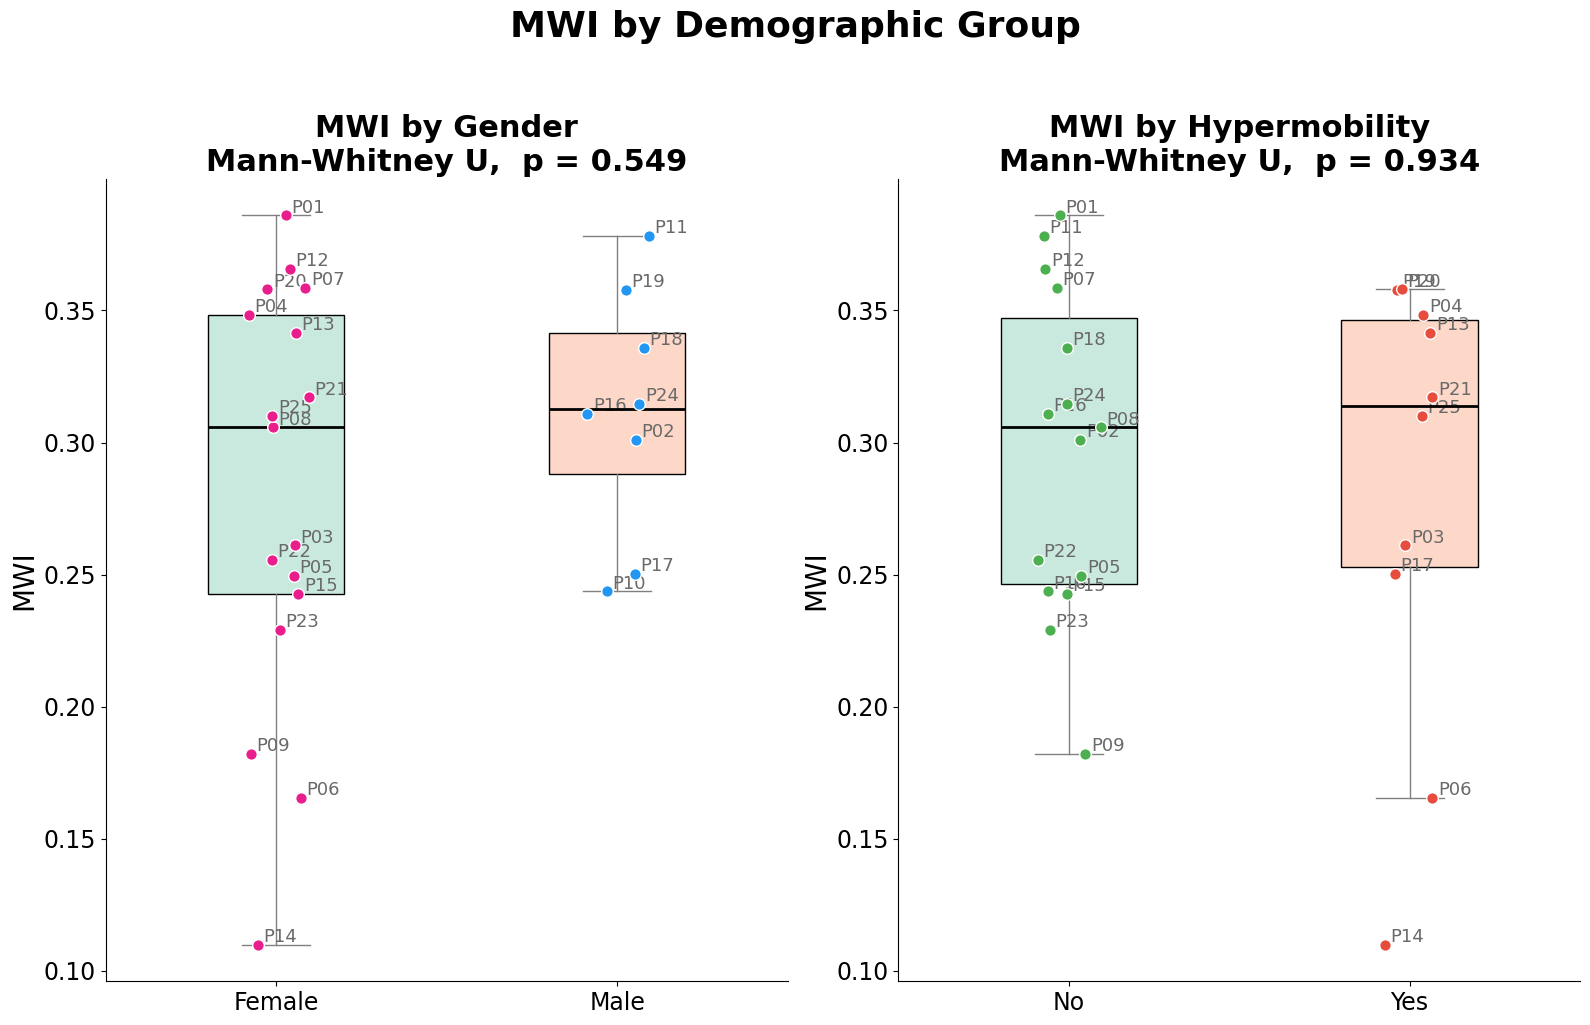

In [79]:
GROUP_VARS = [
    ('gender',        'Gender',        {'Female': '#e91e8c', 'Male': '#2196F3'}),
    ('hypermobility', 'Hypermobility', {'Yes': '#e74c3c',   'No':  '#4caf50'}),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))
rng = np.random.default_rng(42)

for ax, (col, label, pal) in zip(axes, GROUP_VARS):
    sub    = df_enc[['mwi', col, 'name']].dropna()
    groups = sorted(sub[col].unique())

    for i, grp in enumerate(groups):
        grp_data = sub[sub[col] == grp]
        vals     = grp_data['mwi'].values
        names    = grp_data['name'].values
        color    = pal.get(str(grp), plt.cm.Set2.colors[i])

        ax.boxplot(vals, positions=[i], widths=0.4, patch_artist=True,
                   medianprops=dict(color='black', lw=2),
                   boxprops=dict(facecolor=(*plt.cm.Set2.colors[i][:3], 0.35)),
                   whiskerprops=dict(color='grey'), capprops=dict(color='grey'),
                   flierprops=dict(marker=''), zorder=3)
        jitter = rng.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals,
                   color=color, s=70, zorder=4, edgecolor='white')
        for j, (v, name) in enumerate(zip(vals, names)):
            ax.annotate(name, (i + jitter[j], v), fontsize=13, color='dimgrey',
                        xytext=(4, 2), textcoords='offset points')

    g1, g2 = [sub[sub[col] == g]['mwi'].values for g in groups]
    _, p   = _stats.mannwhitneyu(g1, g2, alternative='two-sided')
    p_str  = f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'

    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels([str(g) for g in groups], fontsize=17)
    ax.set_ylabel('MWI', fontsize=20)
    ax.tick_params(axis='y', labelsize=17)
    ax.set_title(f'MWI by {label}\nMann-Whitney U,  {p_str}',
                 fontweight='bold', fontsize=22)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('MWI by Demographic Group', fontsize=26, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


## 4. Correspondence Analysis



In [56]:
# Bin continuous/high-cardinality variables for CA
df['sleep_quality_bin'] = pd.cut(
    df['sleep_quality'],
    bins=[-0.1, 4, 7, 10],
    labels=['Low (<4)', 'Moderate (4–7)', 'High (≥7)']
)

df['stress_score_bin'] = pd.cut(
    df['stress_score'],
    bins=[-0.1, 1, 2, 10],
    labels=['Low (<1)', 'Moderate (1–2)', 'High (≥2)']
)

df['sedentary_score_bin'] = pd.cut(
    df['sedentary_score'],
    bins=[-0.1, 2, 5, 10],
    labels=['Low (0–2)', 'Moderate (3–5)', 'High (≥6)']
)

df['bmi_bin'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 100],
    labels=['Underweight (<18.5)', 'Normal (18.5–25)', 'Overweight (≥25)']
)

# Convert ordinal numerics to string so they appear as categories in crosstab
for col in ['physical_recovery', 'mental_recovery', 'sitting_time']:
    df[col] = df[col].astype(str)

print("Binned columns created.")
for col in ['sleep_quality_bin','stress_score_bin','sedentary_score_bin','bmi_bin']:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

Binned columns created.
  sleep_quality_bin: {'Moderate (4–7)': 11, 'High (≥7)': 10, 'Low (<4)': 4}
  stress_score_bin: {'Low (<1)': 11, 'Moderate (1–2)': 11, 'High (≥2)': 3}
  sedentary_score_bin: {'Low (0–2)': 11, 'Moderate (3–5)': 11, 'High (≥6)': 3}
  bmi_bin: {'Normal (18.5–25)': 21, 'Overweight (≥25)': 3, 'Underweight (<18.5)': 1}


### 4.1 Association Screening

For each variable:
- **Permutation χ²** (B = 4 999) — empirical p-value unaffected by small expected counts
- **Cramér's V** (bias-corrected) — effect size
- **p_fdr** — Benjamini–Hochberg adjusted p across all 16 tests

> Variables with near-zero variance (one category > 80% of sample) are flagged ⚠ — their CA biplots are unreliable.

In [ ]:
CAT_VARS = [
    ('age_group',           'Age Group'),
    ('gender',              'Gender'),
    ('early_life_training', 'Early-life Training'),
    ('end_range_control',   'End-range Control'),
    ('weekly_volume',       'Weekly Volume'),
    ('injury_presence',     'Injury Presence'),
    ('chronic_pain',        'Chronic Pain'),
    ('sleep_duration',      'Sleep Duration'),
    ('hypermobility',       'Hypermobility'),
    ('physical_recovery',   'Physical Recovery'),
    ('mental_recovery',     'Mental Recovery'),
    ('sitting_time',        'Sitting Time (hrs)'),
    ('sleep_quality_bin',   'Sleep Quality'),
    ('stress_score_bin',    'Stress Score'),
    ('sedentary_score_bin', 'Sedentary Score'),
    ('bmi_bin',             'BMI'),
]

def cramers_v(chi2, n, r, c):
    """Cramér's V with bias correction (Bergsma 2013)."""
    phi2  = chi2 / n
    phi2c = max(0, phi2 - (c - 1) * (r - 1) / (n - 1))
    rc    = min(r - (r - 1)**2 / (n - 1), c - (c - 1)**2 / (n - 1))
    return np.sqrt(phi2c / rc) if rc > 0 else 0.0

def perm_chi2(df_sub, row_col, col_col, B=4999, seed=42):
    """Permutation chi-square: shuffle row labels B times under H0."""
    rng  = np.random.default_rng(seed)
    ct   = pd.crosstab(df_sub[row_col], df_sub[col_col])
    obs_stat, _, _, expected = chi2_contingency(ct, correction=False)
    min_exp  = float(expected.min())
    row_vals = df_sub[row_col].values.copy()
    col_vals = df_sub[col_col].values

    count = 0
    for _ in range(B):
        rng.shuffle(row_vals)
        ct_p = pd.crosstab(
            pd.Series(row_vals, name=row_col),
            pd.Series(col_vals, name=col_col)
        ).reindex(index=ct.index, columns=ct.columns, fill_value=0)
        try:
            perm_stat, _, _, _ = chi2_contingency(ct_p, correction=False)
            if perm_stat >= obs_stat:
                count += 1
        except Exception:
            pass

    p_perm = (count + 1) / (B + 1)
    return obs_stat, p_perm, min_exp

# ── Run tests ─────────────────────────────────────────────────────────────────
print('Running permutation χ² tests (B = 4 999) …')
results = []
for col, label in CAT_VARS:
    sub = df[['training_category', col]].dropna()
    ct  = pd.crosstab(sub['training_category'], sub[col])
    r, c = ct.shape

    chi2_obs, p_perm, min_exp = perm_chi2(sub, 'training_category', col)
    v    = cramers_v(chi2_obs, len(sub), r, c)

    # Flag near-zero-variance variables (dominant category > 80%)
    dom_pct = float(ct.sum(axis=0).max() / ct.sum().sum())
    warn    = ' ⚠' if dom_pct > 0.80 else ''

    results.append({
        'Variable':    label,
        'col':         col,
        'χ²':          round(chi2_obs, 3),
        'min_exp':     round(min_exp, 2),
        'p_perm':      p_perm,
        "Cramér's V":  round(v, 3),
        'warn':        warn,
    })
    print(f'  {label:<28} χ²={chi2_obs:6.3f}  p={p_perm:.3f}  V={v:.3f}{warn}')

res_df = pd.DataFrame(results)

_, p_fdr, _, _ = multipletests(res_df['p_perm'].values, alpha=0.05, method='fdr_bh')
res_df['p_fdr'] = np.round(p_fdr, 3)

# ── Display table 
display_df = res_df[['Variable', 'χ²', 'min_exp', 'p_perm', 'p_fdr', "Cramér's V", 'warn']].copy()
display_df['p_perm'] = display_df['p_perm'].map(lambda x: f'{x:.3f}')
display_df['p_fdr']  = display_df['p_fdr'].map(lambda x: f'{x:.3f}')

print('\n' + '=' * 75)
print('ASSOCIATION SCREENING  —  Permutation χ²  +  Cramér\'s V  +  BH-FDR')
print('=' * 75)
print(display_df.to_string(index=False))
print('\n* p_fdr < 0.05 survives FDR correction   ⚠ near-zero variance (CA unreliable)')

Running permutation χ² tests (B = 4 999) …
  Age Group                    χ²= 7.006  p=0.722  V=0.000
  Gender                       χ²=10.185  p=0.012  V=0.380
  Early-life Training          χ²=14.751  p=0.260  V=0.158
  End-range Control            χ²= 4.770  p=0.932  V=0.000
  Weekly Volume                χ²=19.768  p=0.014  V=0.339
  Injury Presence              χ²= 2.044  p=0.649  V=0.000
  Chronic Pain                 χ²=13.588  p=0.031  V=0.322
  Sleep Duration               χ²= 5.760  p=0.474  V=0.000 ⚠
  Hypermobility                χ²= 5.714  p=0.144  V=0.230
  Physical Recovery            χ²=25.395  p=0.033  V=0.328
  Mental Recovery              χ²=10.390  p=0.891  V=0.000
  Sitting Time (hrs)           χ²= 7.658  p=0.290  V=0.141
  Sleep Quality                χ²= 9.070  p=0.184  V=0.200
  Stress Score                 χ²= 9.372  p=0.150  V=0.210
  Sedentary Score              χ²= 2.835  p=0.903  V=0.000
  BMI                          χ²=10.408  p=0.092  V=0.242 ⚠

ASSOCIAT

### 4.2 Correspondence Analysis Biplots

One CA biplot per variable.  
- **Blue squares** = `training_category` levels  
- **Red circles** = levels of the target variable  
- Points close together → tendency to co-occur.  
- Variance explained by Dim 1 + Dim 2 shown on axes.

In [ ]:
TC_ORDER = ['Hybrid', 'Low Active', 'Strength-dominant', 'Flexibility-dominant']
TC_COLORS = {'Hybrid': '#2196F3', 'Low Active': '#FF9800',
             'Strength-dominant': '#4CAF50', 'Flexibility-dominant': '#9C27B0'}

ncols = 3
nrows = -(-len(CAT_VARS) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(10*ncols, 9*nrows))
axes = axes.flatten()

for ax, (col, label) in zip(axes, CAT_VARS):
    ct = pd.crosstab(df['training_category'], df[col])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        ax.set_visible(False)
        continue

    dom_pct    = float(ct.sum(axis=0).max() / ct.sum().sum())
    unreliable = dom_pct > 0.80

    ca         = prince.CA(n_components=2, random_state=42).fit(ct)
    row_coords = ca.row_coordinates(ct)
    col_coords = ca.column_coordinates(ct)

    eig          = ca.eigenvalues_
    total_inertia = float(eig.sum())
    n_dims        = len(row_coords.columns)
    pct = [(float(eig[i]) / total_inertia * 100) if total_inertia > 0 else 0
           for i in range(n_dims)]

    def get_xy(coords, idx):
        x = float(coords.loc[idx, 0])
        y = float(coords.loc[idx, 1]) if n_dims >= 2 else 0.0
        return x, y

    for tc in row_coords.index:
        x, y  = get_xy(row_coords, tc)
        color = TC_COLORS.get(tc, '#333333')
        ax.scatter(x, y, marker='s', s=160, color=color, zorder=3)
        ax.annotate(tc, (x, y), textcoords='offset points',
                    xytext=(5, 5), fontsize=13, color=color, fontweight='bold')

    for lev in col_coords.index:
        x, y = get_xy(col_coords, lev)
        ax.scatter(x, y, marker='o', s=110, color='#E53935', zorder=3)
        ax.annotate(str(lev), (x, y), textcoords='offset points',
                    xytext=(5, -10), fontsize=13, color='#E53935')

    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    dim2_lbl = f'Dim 2 ({pct[1]:.1f}%)' if n_dims >= 2 else 'Dim 2 (1D only)'
    ax.set_xlabel(f'Dim 1 ({pct[0]:.1f}%)', fontsize=20)
    ax.set_ylabel(dim2_lbl, fontsize=20)
    title_suffix = '  ⚠' if unreliable else ''
    ax.set_title(f'training_category × {label}{title_suffix}', fontsize=20, fontweight='bold')
    ax.tick_params(labelsize=17)
    if unreliable:
        ax.patch.set_facecolor('#fff8e1')

for ax in axes[len(CAT_VARS):]:
    ax.set_visible(False)

plt.suptitle('Correspondence Analysis — Training Category × Categorical Variables',
             fontsize=24, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary 
cv_col = "Cramér's V"
print('=' * 75)
print("SUMMARY  —  Permutation χ²  +  Cramér's V  +  BH-FDR")
print('=' * 75)
print(display_df.to_string(index=False))
print('\n* p_fdr < 0.05   ⚠ near-zero variance')
print()

strong = res_df[(res_df[cv_col] >= 0.3) & (res_df['p_fdr'] < 0.05)]
if not strong.empty:
    print('Variables surviving FDR correction with V ≥ 0.3:')
    for _, row in strong.iterrows():
        print(f"  {row['Variable']:<28}  V = {row[cv_col]:.3f}  p_fdr = {row['p_fdr']:.3f}")
else:
    print('No variables survive FDR correction at V ≥ 0.3.')
